In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

In [2]:
from scipy.stats.distributions import norm

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

### Normal Distribution

Recall the probability density function of the normal distribution:

$$
p(x|\mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} e ^{-(x - \mu)^2/(2\sigma^2)}.
$$

In other words, given some properties of the distribution, the mean $\mu$ and the standard deviation $\sigma$, the function above described the probability *density* as a function of parameter $x\in(-\infty, \infty)$.

So if we want to look at what this distribution looks like a function of $x$, we can just evaluate this function at a bunch of $x$ values and plot it.

In [3]:
def pdf(x, mu=10, sigma=2.):
    return 1/np.sqrt(2*np.pi*sigma**2) * np.exp(-(x - mu)**2/(2*sigma**2))

In [4]:
mu = 10.
sigma = 2.

xs = np.linspace(mu - 5*sigma, mu + 5*sigma, 100)

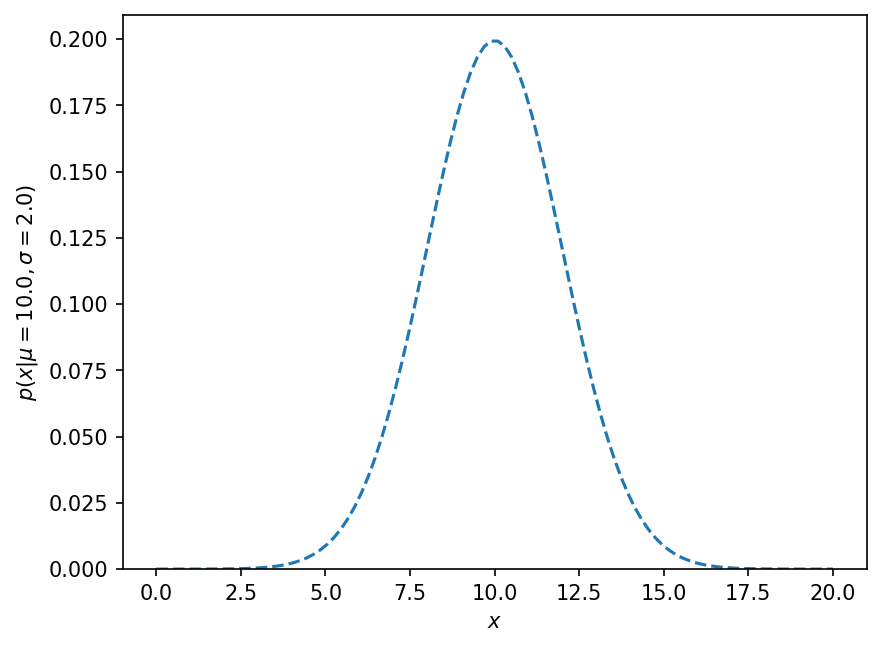

In [5]:
mu = 10.
sigma = 2.

xs = np.linspace(mu - 5*sigma, mu + 5*sigma, 100)

plt.plot(xs, pdf(xs), ls='--')
plt.ylim(ymin=0)

plt.ylabel(r'$p(x|\mu={}, \sigma={})$'.format(mu, sigma))
plt.xlabel('$x$');

What if we didn't know the function form of the probability density function?  If we had a method of draws samples from the distribution, we can look at the distribution of those samples to get an idea of the shape of the probability density function.

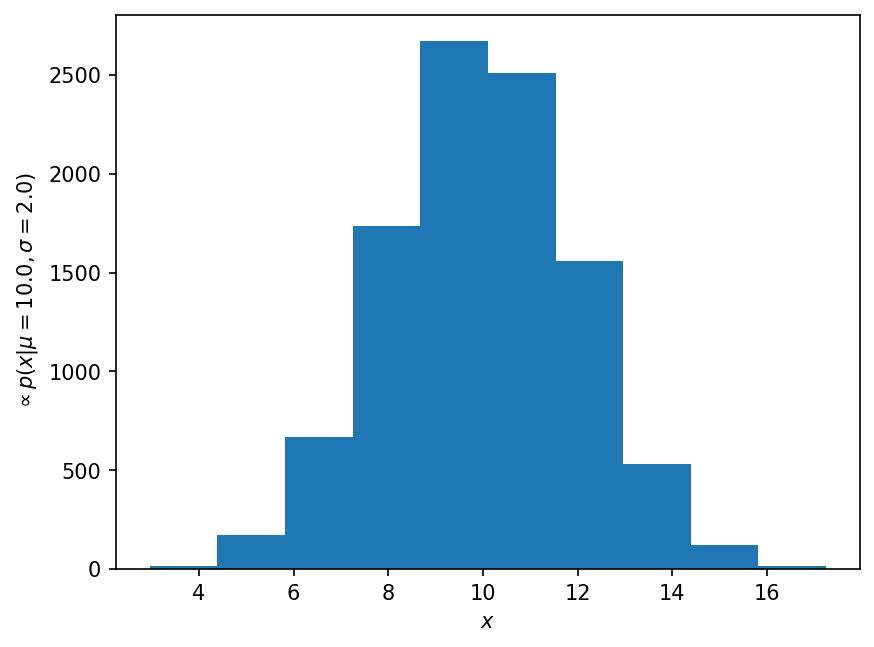

In [6]:
N = 10000

samples = norm.rvs(loc=mu, scale=sigma, size=N)
plt.hist(samples)

plt.ylabel(r'$\propto p(x|\mu={}, \sigma={})$'.format(mu, sigma))
plt.xlabel('$x$');

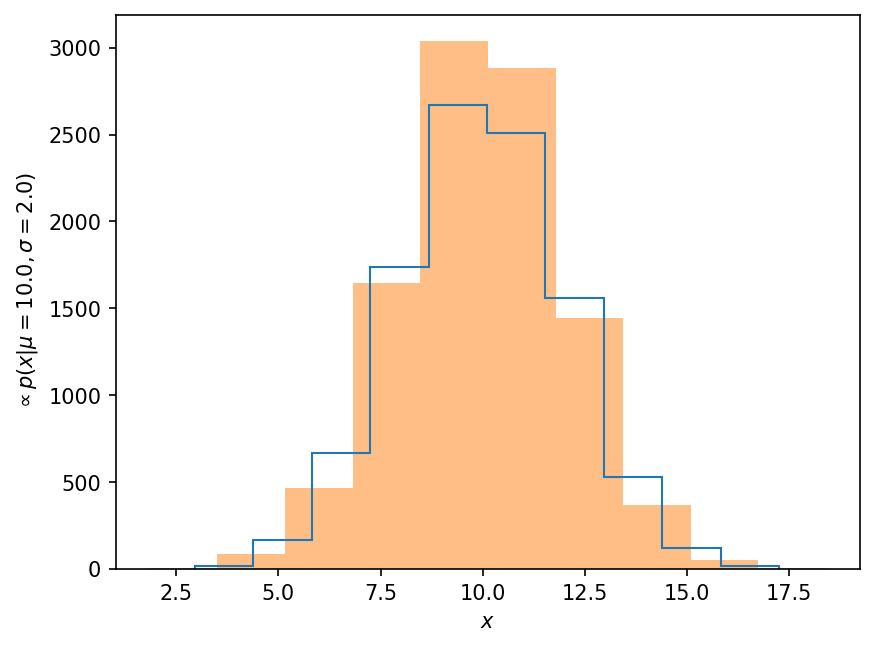

In [7]:
N = 10000

last_samples = samples
samples = norm.rvs(loc=mu, scale=sigma, size=N)
plt.hist(last_samples, histtype='step')
plt.hist(samples, alpha=0.5)

plt.ylabel(r'$\propto p(x|\mu={}, \sigma={})$'.format(mu, sigma))
plt.xlabel('$x$');

The more samples we have, the better we estimate the distribution.

In [8]:
def plot_dist(N=100, mu=10, sigma=5):
    xs = np.linspace(mu - 5*sigma, mu + 5*sigma, 100)

    plt.plot(xs, norm.pdf(xs, loc=mu, scale=sigma))

    samples = norm.rvs(loc=mu, scale=sigma, size=N)
    plt.hist(samples, bins=30, alpha=0.5, density=True)

    plt.ylabel(r'$p(x|\mu={}, \sigma={})$'.format(mu, sigma))
    plt.xlabel('$x$')
    plt.ylim(0, .3)

In [9]:
interactive(plot_dist, N=(100, 10000), sigma=(1e-1, 10))

interactive(children=(IntSlider(value=100, description='N', max=10000, min=100), IntSlider(value=10, descripti…

# Monte Carlo Methods

Monte Carlo methods use randomness to solve problems, typically for optimization, numerical integration, and generating samples from a probability distribution.  The name originates from their first use in solving problems in the Monte Carlo Casino in Monaco.

Generally the process goes like:
1. Define a domain of valid inputs.
1. Generate inputs from some probability distribution randomly over the domain.
1. Perform a deterministic computation of the outputs.
1. Collect the results.

### Coin Flipping
As a simple example, let's make a biased coin and perform some flips to determine its bias.


In [10]:
true_bias = np.random.random()

In [11]:
def flip_coin(nflips=20, coin_bias=true_bias):
    obs = []

    random_inputs = np.random.random(nflips)
    for inp in random_inputs:
        # Bernoulli Trials
        if inp < coin_bias:
            obs.append(True)
        else:
            obs.append(False)
    return obs

The fraction of `True` outcomes gives us an estimate of the bias.

In [12]:
np.mean(flip_coin())

np.float64(0.8)

### Estimate $\pi$

We can use Monte Carlo methods to estimate $\pi$ using uniform random numbers.  Think about throwing darts at a unit square dart board with a quadrant inscribed on it.

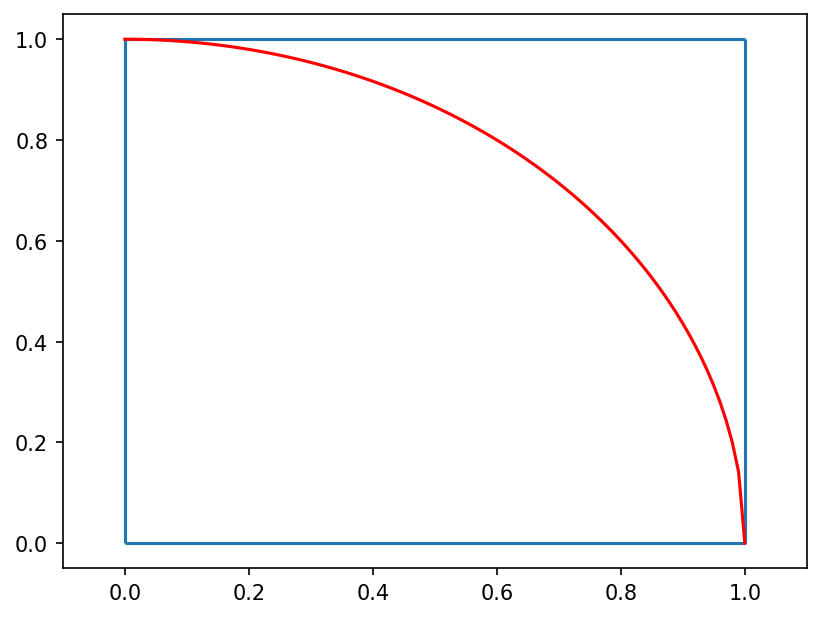

In [13]:
def plot_dart_board(darts=None):
    plt.vlines([0, 1], 0, 1)
    plt.hlines([0, 1], 0, 1)

    xs = np.linspace(0, 1, 100)
    plt.plot(xs, np.sqrt(1-xs**2), color='r')

    if darts is not None:
        inside = np.sum(darts**2, axis=1) < 1.
        plt.scatter(darts[inside, 0], darts[inside, 1], color='r', s=1)
        plt.scatter(darts[~inside, 0], darts[~inside, 1], color='b', s=1)
    plt.xlim(-.1, 1.1)

plot_dart_board()

np.float64(3.28)

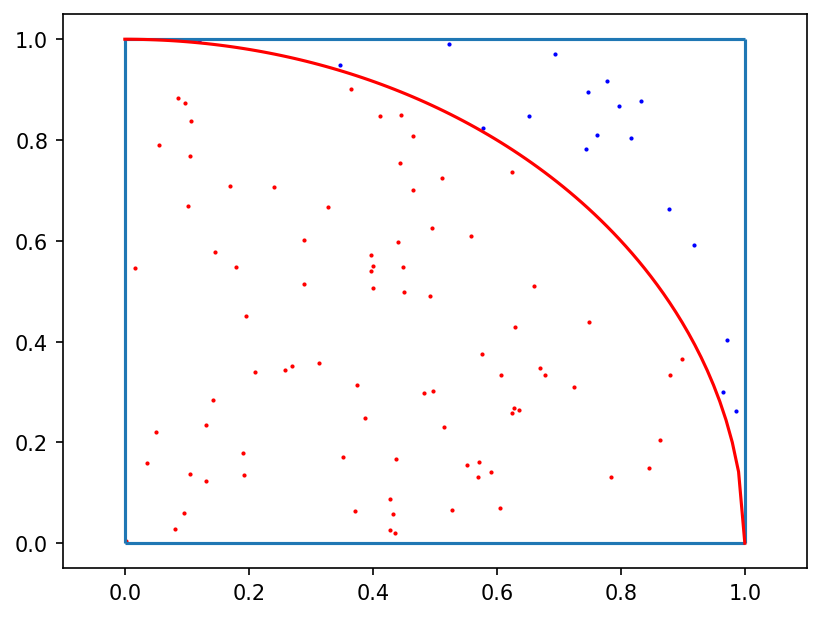

In [14]:
ndarts = 100

darts = np.random.random((ndarts, 2))
inside_quadrant = np.sum(darts**2, axis=1) < 1

plot_dart_board(darts)

4 * np.count_nonzero(inside_quadrant)/ndarts

## Rejection Sampling

Now let's explore ways to generate samples from a distribution when we only know the functional form of its PDF.  Rejection sampling is one approach.

We'll refer to the target distribution that we want to draw samples from as $p(x)$. We can use another distribution $g(x)$ that we *can* draw samples from (whose PDF encompases the whole target distribution after rescaling by some value $k$) to draw samples from the target distribution.

We do so by drawing a sample $z$ from our sampling distribution.  We then generate a random number $u$ unifomly between 0 and $k*g(z)$.  If $u \leq p(z)$ the we save the sample.

In [15]:
import seaborn as sns

In [16]:
mu = 10
sigma = 2.

def p(x):
    '''The target distribution to draw samples from'''
    return pdf(x, mu=mu, sigma=sigma)

def g(x):
    '''A distribution we can draw samples from'''
    return np.ones_like(x)


x = np.linspace(-50, 50, 1000)
k = .4 #max(p(x) / g(x))

def rejection_sampling(iter=1000):
    samples = []

    for i in range(iter):
        z = np.random.uniform(-50, 50)
        u = np.random.uniform(0, k*g(z))

        if u <= p(z):
            samples.append(z)

    return np.array(samples)

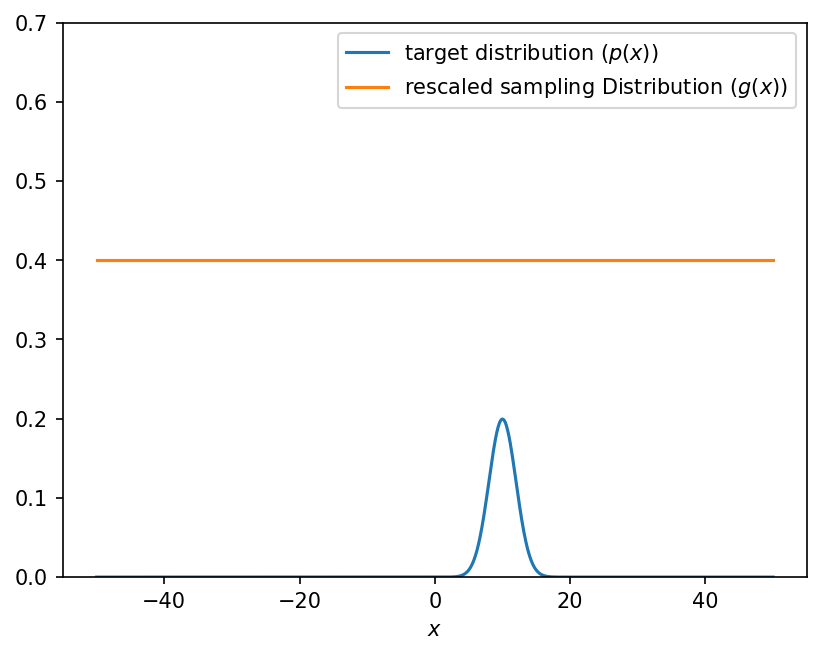

In [17]:
plt.plot(x, p(x), label='target distribution ($p(x)$)')
plt.plot(x, k*g(x), label='rescaled sampling Distribution ($g(x)$)')

plt.ylim(0, .7)
plt.legend()
plt.xlabel('$x$');

In [18]:
s = rejection_sampling(iter=100000)
print("{} samples drawn from target distribution".format(len(s)))

2537 samples drawn from target distribution


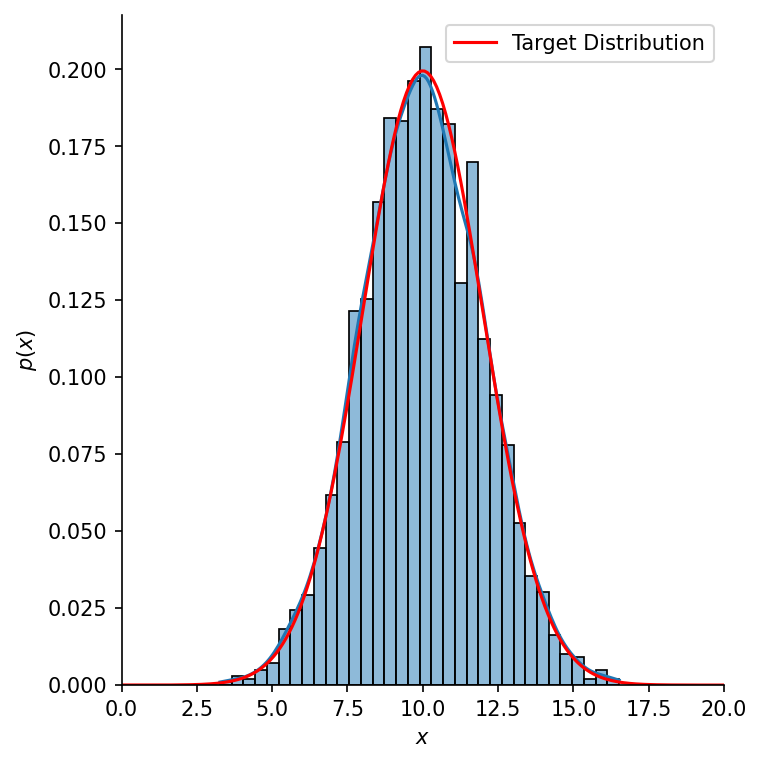

In [19]:
sns.displot(s, stat='density', kde=True)
plt.plot(x, p(x), color='r', label='Target Distribution')
plt.legend()
plt.xlim(0, 20)
plt.xlabel('$x$')
plt.ylabel('$p(x)$');